# Tutorial 1 — Function Fitting with Equality Constraints

This tutorial shows how to use **ENFORCE** to fit a function subject to a nonlinear equality constraint, recovering feasibility to within tolerance ε at every prediction.

**Problem:** learn the mapping

$$x \mapsto (\cos(\pi x),\; \sin(\pi x)), \quad x \in [-1, 1]$$

subject to the **unit-circle constraint**

$$c(x, y) = y_1^2 + y_2^2 - 1 = 0$$

A plain MLP can violate this constraint. ENFORCE recovers feasibility on every prediction
such that it lies on the unit circle by projecting $\hat{y}$ onto the constraint
manifold via neural projection at training and inference time.

---

## Outline
1. Generate training data  
2. Scale inputs and outputs  
3. Define the equality constraint  
4. Configure and instantiate ENFORCE  
5. Train with `Trainer`  
6. Evaluate with `Evaluator`  
7. Visualise results and check constraint residuals  

In [1]:
import sys, pathlib
_here = pathlib.Path.cwd()
_root = _here if (_here / "src").exists() else _here.parent
sys.path.insert(0, str(_root))

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.enforce.config import ENFORCEConfig
from src.enforce.model import ENFORCE
from src.engines.train import Trainer, TrainingConfig
from src.engines.evaluate import Evaluator, EvaluationConfig
from src.data.data_utils import generate_data, scale_data

np.random.seed(42)
torch.manual_seed(42)

## 1. Generate Training Data

`generate_data` takes a list of scalar-output functions.  Each function receives
the transposed input array (shape `[NI, N]`) and must return a 1-D array of
shape `[N]`.

- **NI** — number of input features (here NI=1, a single scalar x)
- **N** — number of data samples

The resulting `y_train` has shape `[N, 2]` — one column per output function.

In [2]:
def cos_pi(x):  # x has shape [1, N]
    return np.cos(np.pi * x[0])

def sin_pi(x):
    return np.sin(np.pi * x[0])

N_TRAIN, N_TEST = 50, 2000

x_train, y_train = generate_data([cos_pi, sin_pi], N_TRAIN, left_limit=-1.0, right_limit=1.0)
x_test,  y_test  = generate_data([cos_pi, sin_pi], N_TEST,  left_limit=-1.0, right_limit=1.0)

print(f"x_train: {x_train.shape},  y_train: {y_train.shape}")

# Sanity-check: all training labels lie on the unit circle
residuals = y_train[:, 0]**2 + y_train[:, 1]**2 - 1.0
print(f"Max training label constraint residual: {np.abs(residuals).max():.2e}  (should be ~0)")

x_train: (50, 1),  y_train: (50, 2)
Max training label constraint residual: 2.22e-16  (should be ~0)


## 2. Scale Inputs and Outputs

`scale_data` computes per-feature z-score statistics from the **training set**
and applies the same transform to both train and test splits.  The returned
`scaling_params` dict is later needed by `Evaluator` to convert predictions
back to the original (unscaled) space.

In [3]:
x_tr_s, y_tr_s, x_te_s, y_te_s, sp = scale_data(x_train, y_train, x_test, y_test)

# Convert to float32 tensors (ENFORCE operates on float32 internally)
x_tr_t = torch.tensor(x_tr_s, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr_s, dtype=torch.float32)
x_te_t = torch.tensor(x_te_s, dtype=torch.float32)
y_te_t = torch.tensor(y_te_s, dtype=torch.float32)

# ENFORCE expects scaling statistics as (mean, std) tensor pairs
scaling_input  = (
    torch.tensor(sp["input_mean"],  dtype=torch.float32),
    torch.tensor(sp["input_std"],   dtype=torch.float32),
)
scaling_output = (
    torch.tensor(sp["output_mean"], dtype=torch.float32),
    torch.tensor(sp["output_std"],  dtype=torch.float32),
)

## 3. Define the Equality Constraint

The constraint function must have the signature

```python
def c(x: Tensor[BS, NI], y: Tensor[BS, NO]) -> Tensor[BS, NC]
```

- **BS** — batch size (number of samples in the current mini-batch)

Both `x` and `y` are **unscaled** — ENFORCE un-scales them automatically
before calling `c`.  Return a tensor of shape `[BS, NC]` where each column is
one constraint residual that must equal zero.

In [4]:
def circle_constraint(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """Unit-circle equality: y1^2 + y2^2 - 1 = 0.  Returns shape [BS, 1]."""
    return (y[:, 0] ** 2 + y[:, 1] ** 2 - 1.0).unsqueeze(1)

## 4. Configure and Instantiate ENFORCE

`ENFORCEConfig` holds all hyper-parameters.  Key fields:

| Field | Meaning |
|---|---|
| `input_neurons` / `output_neurons` | network I/O dimensionality |
| `training_tolerance` | convergence threshold for neural projection during training |
| `inference_tolerance` | neural projection convergence threshold at test time |
| `max_it` | max neural projection iterations per forward pass |
| `ada_np_auto_activation` | skip projection when it would increase the loss |
| `weight_loss_displacement` | penalty weight for the projection displacement |

`ENFORCE` constructor key arguments:

| Arg | Meaning |
|---|---|
| `scaling_input` / `scaling_output` | `(mean, std)` tensors from `scale_data` |
| `c` | the constraint callable |
| `constrained` | `True` → project; `False` → plain MLP (useful for comparison) |
| `weighting_option` | inner-product metric for projection (5 = gradient-based weighting) |

In [5]:
cfg = ENFORCEConfig(
    input_neurons=1,
    hidden_neurons=64,
    output_neurons=2,
    hidden_layers=1,
    training_tolerance=1e-4,
    inference_tolerance=1e-6,
    max_it=100,
    epoch_start_hard_constrained=0,
    ada_np_auto_activation=True,
    supervised=True,
    weight_loss_displacement=0.5,
)

model_enforce = ENFORCE(
    scaling_input=scaling_input,
    scaling_output=scaling_output,
    c=circle_constraint,
    config=cfg,
    constrained=True,
    weighting_option=1,
)

# For comparison: an unconstrained MLP with the same architecture
model_mlp = ENFORCE(
    scaling_input=scaling_input,
    scaling_output=scaling_output,
    c=circle_constraint,
    config=cfg,
    constrained=False,  # <-- no projection
)

print(model_enforce)

ENFORCE(
  (input_layer): Linear(in_features=1, out_features=64, bias=True)
  (hidden_layer): Linear(in_features=64, out_features=64, bias=True)
  (hidden_activation): ReLU()
  (output_layer): Linear(in_features=64, out_features=2, bias=True)
  (loss_function): MSELoss()
)


## 5. Train

`Trainer` encapsulates the Adam training loop.  `fit()` returns the trained
model.

In [6]:
train_cfg = TrainingConfig(
    batch_size=64,
    epochs=2000,
    learning_rate=1e-3,
    random_seed=42,
)

print("Training ENFORCE...")
model_enforce = Trainer(model_enforce, train_cfg).fit(x_tr_t, y_tr_t)

print("\nTraining MLP baseline...")
model_mlp = Trainer(model_mlp, train_cfg).fit(x_tr_t, y_tr_t)

print("\nDone.")

Training ENFORCE...
Start projection: Epoch 39 Iteration: 0 Loss before: 0.32927414774894714 Loss after: 0.3216818869113922
Epoch 100/2000, Loss: 4.96e-02, LossDispl: 6.30e-02, EqMeanResidual: 2.07e-06, EqMaxResidual: 1.54e-05
Epoch 200/2000, Loss: 4.23e-03, LossDispl: 6.77e-03, EqMeanResidual: 3.16e-05, EqMaxResidual: 3.24e-04
Epoch 300/2000, Loss: 1.45e-03, LossDispl: 2.43e-03, EqMeanResidual: 6.05e-06, EqMaxResidual: 8.20e-05
Epoch 400/2000, Loss: 6.80e-04, LossDispl: 1.15e-03, EqMeanResidual: 1.74e-06, EqMaxResidual: 3.28e-05
Epoch 500/2000, Loss: 3.97e-04, LossDispl: 6.69e-04, EqMeanResidual: 7.30e-07, EqMaxResidual: 1.29e-05
Epoch 600/2000, Loss: 2.65e-04, LossDispl: 4.47e-04, EqMeanResidual: 3.86e-07, EqMaxResidual: 4.65e-06
Epoch 700/2000, Loss: 1.89e-04, LossDispl: 3.21e-04, EqMeanResidual: 2.53e-07, EqMaxResidual: 2.98e-06
Epoch 800/2000, Loss: 1.40e-04, LossDispl: 2.40e-04, EqMeanResidual: 1.63e-07, EqMaxResidual: 1.91e-06
Epoch 900/2000, Loss: 1.08e-04, LossDispl: 1.88e-04,

## 6. Evaluate

`Evaluator.evaluate()` runs the model on the test set and returns an
`EvalResult` with:

- `metrics` — R², MSE, NRMSE per output, constraint residuals, projection
  iterations, inference time
- `predictions` — unscaled predictions after projection `[N, NO]`
- `predictions_before_proj` — unscaled network output before projection `[N, NO]`

> **Important:** do **not** wrap evaluation in `torch.no_grad()`.  ENFORCE's
> projection requires autograd to compute Jacobians.

In [7]:
eval_cfg = EvaluationConfig(batch_size=None)  # None = single full-batch pass

result_enforce = Evaluator(model_enforce, eval_cfg).evaluate(x_te_t, y_te_t, sp)
result_mlp     = Evaluator(model_mlp,     eval_cfg).evaluate(x_te_t, y_te_t, sp)

print("=== ENFORCE metrics ===")
for k, v in result_enforce.metrics.items():
    print(f"  {k}: {v}")

Projection iterations inference: 3
Inference time: 0.0221s, EqMeanResidual: 7.96e-08, EqMaxResidual: 3.58e-07
Inference time: 0.0014s, EqMeanResidual: 9.84e-03, EqMaxResidual: 1.57e-01
=== ENFORCE metrics ===
  projection iterations: 3.0
  inference time: 0.022134065628051758
  r2_y1: 0.9999895095825195
  mse_y1: 5.295115443004761e-06
  nrmse_y1: 0.003238371107727289
  mape_y1: 0.011563104577362537
  r2_y2: 0.9999275803565979
  mse_y2: 3.5806431696983054e-05
  nrmse_y2: 0.00850876234471798
  mape_y2: 0.05029687657952309
  residual_avg: 7.957220304888324e-08
  residual_max: 3.5762786865234375e-07


## 7. Visualise and Check Constraint Residuals

In [8]:
# Constraint residuals on test predictions
preds_e = result_enforce.predictions        # [N, 2]
preds_m = result_mlp.predictions

res_enforce = preds_e[:, 0]**2 + preds_e[:, 1]**2 - 1.0
res_mlp     = preds_m[:, 0]**2 + preds_m[:, 1]**2 - 1.0

print(f"ENFORCE  max |y1^2 + y2^2 - 1|: {np.abs(res_enforce).max():.2e}")
print(f"MLP      max |y1^2 + y2^2 - 1|: {np.abs(res_mlp).max():.2e}")

ENFORCE  max |y1^2 + y2^2 - 1|: 3.58e-07
MLP      max |y1^2 + y2^2 - 1|: 1.57e-01


Projection iterations inference: 3


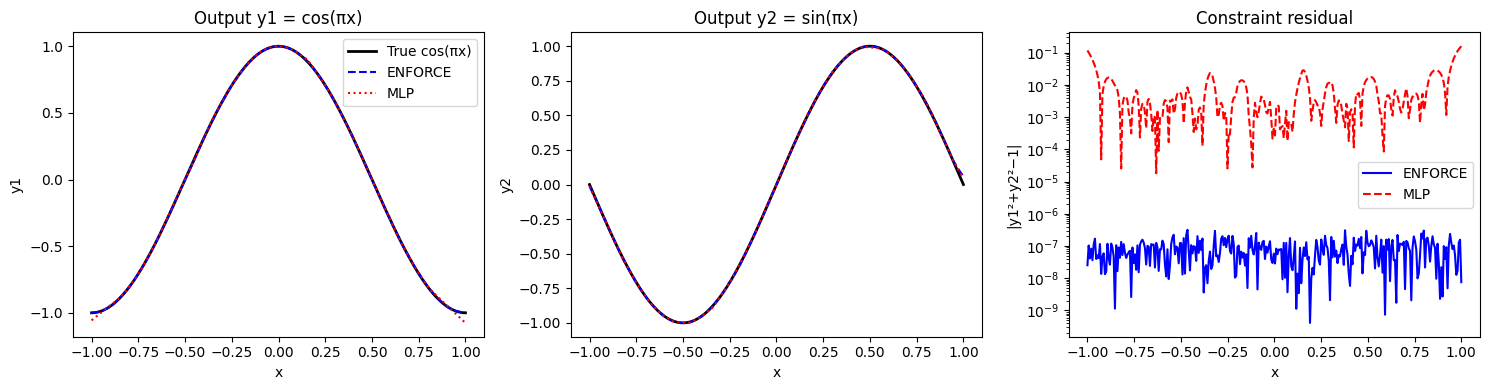

In [9]:
# Predictions over a dense grid
x_grid = np.linspace(-1, 1, 300).reshape(-1, 1).astype(np.float32)
x_grid_s = (x_grid - sp["input_mean"]) / sp["input_std"]
x_grid_t = torch.tensor(x_grid_s, dtype=torch.float32)

model_enforce.eval()
model_mlp.eval()

with torch.enable_grad():
    # predict() returns (y_after_proj, y_before_proj, proj_iter)
    y_grid_s_e, _, _ = model_enforce.predict(x_grid_t)
    y_grid_s_m, _, _ = model_mlp.predict(x_grid_t)

# Un-scale
y_grid_e = (y_grid_s_e.detach().numpy() * sp["output_std"] + sp["output_mean"]).astype(float)
y_grid_m = (y_grid_s_m.detach().numpy() * sp["output_std"] + sp["output_mean"]).astype(float)
y_true   = np.column_stack([np.cos(np.pi * x_grid[:, 0]), np.sin(np.pi * x_grid[:, 0])])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# y1 prediction
ax = axes[0]
ax.plot(x_grid, y_true[:, 0], 'k-',  label='True cos(πx)', linewidth=2)
ax.plot(x_grid, y_grid_e[:, 0], 'b--', label='ENFORCE', linewidth=1.5)
ax.plot(x_grid, y_grid_m[:, 0], 'r:',  label='MLP', linewidth=1.5)
ax.set_xlabel('x'); ax.set_ylabel('y1'); ax.legend(); ax.set_title('Output y1 = cos(πx)')

# y2 prediction
ax = axes[1]
ax.plot(x_grid, y_true[:, 1], 'k-',  linewidth=2)
ax.plot(x_grid, y_grid_e[:, 1], 'b--', linewidth=1.5)
ax.plot(x_grid, y_grid_m[:, 1], 'r:',  linewidth=1.5)
ax.set_xlabel('x'); ax.set_ylabel('y2'); ax.set_title('Output y2 = sin(πx)')

# Constraint residual
res_e_grid = y_grid_e[:, 0]**2 + y_grid_e[:, 1]**2 - 1.0
res_m_grid = y_grid_m[:, 0]**2 + y_grid_m[:, 1]**2 - 1.0
ax = axes[2]
ax.semilogy(x_grid, np.abs(res_e_grid) + 1e-16, 'b-',  label='ENFORCE')
ax.semilogy(x_grid, np.abs(res_m_grid) + 1e-16, 'r--', label='MLP')
ax.set_xlabel('x'); ax.set_ylabel('|y1²+y2²−1|'); ax.legend()
ax.set_title('Constraint residual')

plt.tight_layout()
plt.show()

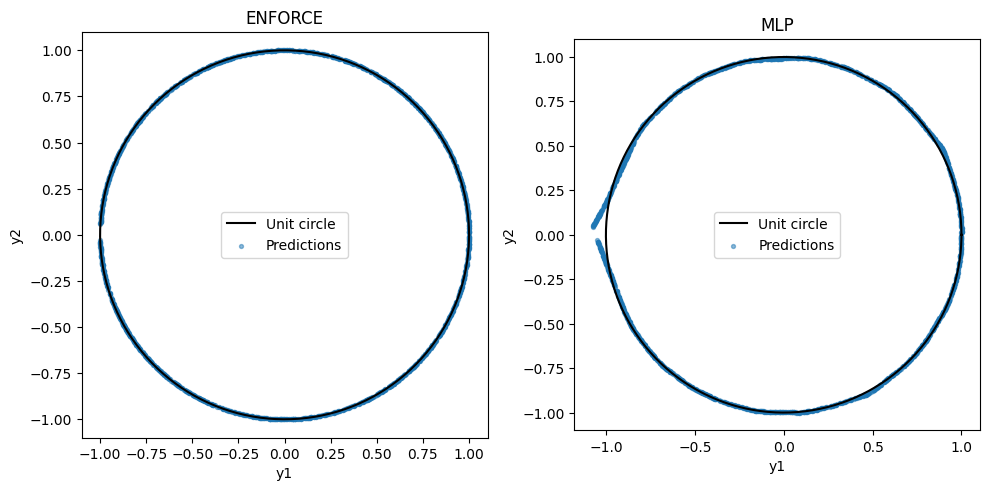

In [10]:
# Scatter in output space: predictions should lie on the unit circle
theta = np.linspace(0, 2 * np.pi, 300)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, preds, title in zip(axes, [preds_e, preds_m], ['ENFORCE', 'MLP']):
    ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1.5, label='Unit circle')
    ax.scatter(preds[:, 0], preds[:, 1], s=8, alpha=0.5, label='Predictions')
    ax.set_aspect('equal'); ax.set_xlabel('y1'); ax.set_ylabel('y2')
    ax.set_title(title); ax.legend()

plt.tight_layout()
plt.show()

## Summary

| Model | Max constraint residual |
|---|---|
| ENFORCE | ≈ 1e-6 (within `inference_tolerance`) |
| Plain MLP | depends on training — typically 1e-2 to 1e-1 |

ENFORCE reduces the constraint residual below `inference_tolerance` at every prediction,
regardless of how well the base network fits the data.

### Key API recap
```python
# 1. Define the constraint  c(x, y) -> [BS, NC]
def my_constraint(x, y): ...

# 2. Scale data
x_tr_s, y_tr_s, x_te_s, y_te_s, sp = scale_data(x_train, y_train, x_test, y_test)
scaling_input  = (torch.tensor(sp['input_mean']),  torch.tensor(sp['input_std']))
scaling_output = (torch.tensor(sp['output_mean']), torch.tensor(sp['output_std']))

# 3. Configure and build
cfg   = ENFORCEConfig(input_neurons=1, output_neurons=2, ...)
model = ENFORCE(scaling_input, scaling_output, c=my_constraint, config=cfg)

# 4. Train
model = Trainer(model, TrainingConfig(epochs=2000)).fit(x_tr_t, y_tr_t)

# 5. Evaluate  (no torch.no_grad() — Jacobians need autograd)
result = Evaluator(model, EvaluationConfig()).evaluate(x_te_t, y_te_t, sp)
predictions = result.predictions  # unscaled, shape [N, NO]
```